# A Simple Memory Experiment

This notebook constructs a code, a corresponding syndrome extraction circuit, memory experiment, and plots the results. Where possible, it uses pre-existing tools.

In [1]:
import numpy as np
import stim
import sinter
from matplotlib import pyplot as plt

import ldpc.codes
from bposd.hgp import hgp
from bposd.css import css_code

from circuit_builder import build_memory_circuit

print("stim", stim.__version__)
print("sinter", sinter.__version__)

stim 1.16.dev1768963940
sinter 1.16.dev1768963940


## 1) Build codes

In [2]:
codes = {
    "13,1,3":   (ldpc.codes.rep_code(3), ldpc.codes.rep_code(3)),
    "27,4,3":   (ldpc.codes.rep_code(3), ldpc.codes.hamming_code(3)),
    "47,4,3":   (ldpc.codes.rep_code(5), ldpc.codes.hamming_code(3)),
    "53,11,3":  (ldpc.codes.rep_code(3), ldpc.codes.hamming_code(4)),
    "58,16,3":  (ldpc.codes.hamming_code(3), ldpc.codes.hamming_code(3)),
    "117,44,3": (ldpc.codes.hamming_code(3), ldpc.codes.hamming_code(4)),
    "241,141,3": (ldpc.codes.hamming_code(4), ldpc.codes.hamming_code(4)),
    "306,36,?": (ldpc.codes.random_binary_code(9, 15, 5), ldpc.codes.random_binary_code(9, 15, 5)),
    "325,25,?": (ldpc.codes.random_binary_code(10, 15, 6), ldpc.codes.random_binary_code(10, 15, 6)),
}

h_seed1 = codes["325,25,?"][0]
h_seed2 = codes["325,25,?"][1]
# code = hgp(h1=h_seed1, h2=h_seed2, compute_distance=True)

h_hamming = ldpc.codes.hamming_code(3)
code = css_code(hx=h_hamming, hz=h_hamming)

print(f"Inner Code:    [[{code.N},{code.K},{code.D}]]")

Inner Code:    [[7,1,nan]]


## 2) Circuit construction

Inner:  qubits=10, detectors=12, obs=1


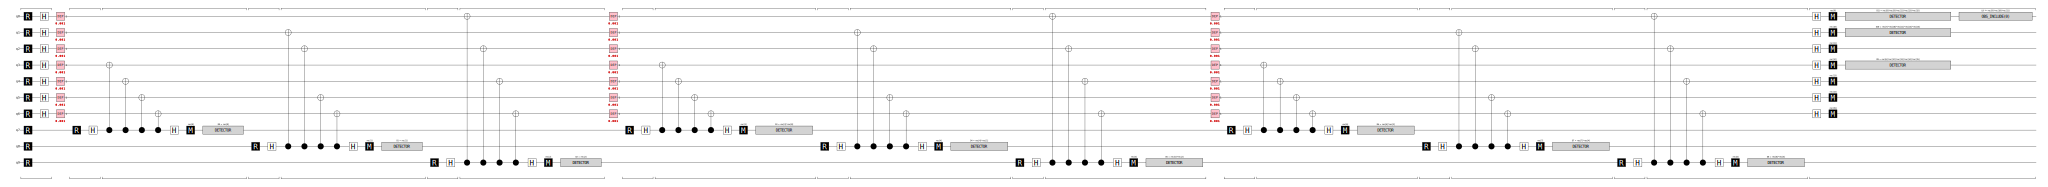

In [3]:
# Quick test
circuit = build_memory_circuit(code, rounds=3, p_data=1e-3, p_meas=0, basis="X")
print(f"Inner:  qubits={circuit.num_qubits}, detectors={circuit.num_detectors}, obs={circuit.num_observables}")
circuit.diagram("timeline-svg")

## 3) Simulation

In [6]:
from sinter_tld import tld
from stimbposd import sinter_decoders

ps = np.logspace(-4, -2, 10)
inner_rounds = 3#int(code.D)

def generate_tasks(basis):
    for p in ps:
        p_data = float(p)
        p_meas = 0.0

        yield sinter.Task(
            circuit=build_memory_circuit(
                code, rounds=inner_rounds, p_data=p_data, p_meas=p_meas, basis=basis),
            decoder='bposd',
            json_metadata={"code": "inner", "basis": basis, "p": p_data,
                           "rounds": inner_rounds, "n_data": int(code.N),
                           "k_in": int(code.K)},
        )

In [7]:
samples = []
for basis in ["Z", "X"]:
    pcm = code.hz if basis == "Z" else code.hx
    samples.extend(sinter.collect(
        num_workers=10,
        max_shots=100_000,
        max_errors=50,
        tasks=generate_tasks(basis),
        decoders=['bposd'],
        custom_decoders=sinter_decoders(),
        print_progress=True,
    ))

Starting 10 workers...
10 tasks left:
  workers decoder eta shots_left errors_left json_metadata                                                       
        1   bposd   ?     100000          50 code=inner,basis=Z,p=0.0001,rounds=3,n_data=7,k_in=1                
        1   bposd   ?     100000          50 code=inner,basis=Z,p=0.0001668100537200059,rounds=3,n_data=7,k_in=1 
        1   bposd   ?     100000          50 code=inner,basis=Z,p=0.0002782559402207126,rounds=3,n_data=7,k_in=1 
        1   bposd   ?     100000          50 code=inner,basis=Z,p=0.00046415888336127773,rounds=3,n_data=7,k_in=1
        1   bposd   ?     100000          50 code=inner,basis=Z,p=0.000774263682681127,rounds=3,n_data=7,k_in=1  
        1   bposd   ?     100000          50 code=inner,basis=Z,p=0.001291549665014884,rounds=3,n_data=7,k_in=1  
        1   bposd   ?     100000          50 code=inner,basis=Z,p=0.002154434690031882,rounds=3,n_data=7,k_in=1  
        1   bposd <1m      98703          40 code=

## 4) Plot results

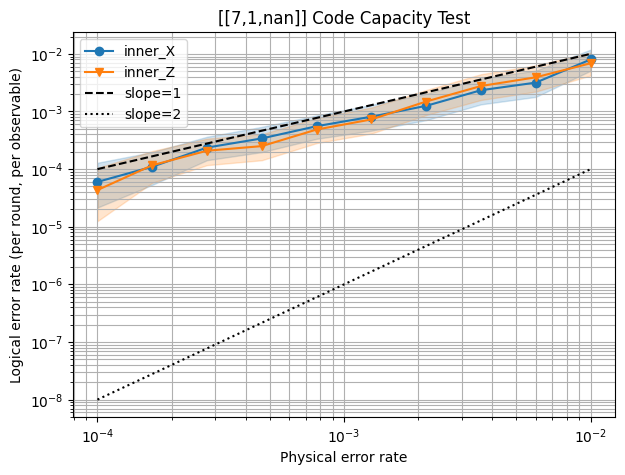

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

# Add label to metadata for grouping
for s in samples:
    md = s.json_metadata
    md["label"] = f"{md['code']}_{md['basis']}"
    # md["prob"] = md["p"]

sinter.plot_error_rate(
    ax=ax,
    stats=samples,
    x_func=lambda stat: stat.json_metadata["p"],
    group_func=lambda stat: stat.json_metadata["label"],
    failure_units_per_shot_func=lambda stat: stat.json_metadata["rounds"],
    failure_values_func=lambda stat: stat.json_metadata["k_in"],
)

# --- Add break-even lines ---
all_ps = sorted(set(s.json_metadata["p"] for s in samples))
if all_ps:
    ps_line = np.array([min(all_ps), max(all_ps)])
    ax.plot(ps_line, ps_line, "k--", label="slope=1")
    ax.plot(ps_line, ps_line**2, "k:", label="slope=2")

ax.set(xscale="log", yscale="log",
       xlabel="Physical error rate",
       ylabel="Logical error rate (per round, per observable)",
       title=f"[[{code.N},{code.K},{code.D}]] Code Capacity Test")
ax.grid(True, which="both")
ax.legend()
plt.show()